# 05: Backtest Report

**Thin client** over `src/portfolio` and `src/backtest`. Builds the long-only top-N
portfolio from OOS predictions, runs the cost-aware backtest, and attributes returns
to FF5 + momentum.

> Quick ~30-ticker sample: with `n_holdings` ≈ universe size the portfolio is ~the
> whole universe, so turnover is tiny and the strategy ≈ benchmark. Real
> differentiation needs the full universe (drop `--quick`). All metrics are
> reported with the **survivorship-bias caveat** (current-membership universe).”

In [1]:
import sys; sys.path.insert(0, '..')
import warnings; warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt

from src.data import cache
from src.portfolio.construct import build_portfolio
from src.backtest import engine, metrics, attribution

plt.style.use('seaborn-v0_8-whitegrid')

preds   = cache.load('predictions.parquet')
factors = cache.load('ff5_monthly.parquet')

portfolio = build_portfolio(preds)
bt   = engine.run_backtest(portfolio, preds)
bench = engine.benchmark_return(preds)
print('backtest months:', len(bt), '| avg holdings/mo:', round(portfolio.groupby('date').size().mean(),1))

backtest months: 192 | avg holdings/mo: 30.0


## Performance vs equal-weight universe

In [2]:
summary = pd.DataFrame({
    'strategy (net)': metrics.performance_summary(bt['net']),
    'benchmark':      metrics.performance_summary(bench),
}).T
summary.round(3)

,ann_return,ann_vol,sharpe,sortino,max_drawdown,hit_rate,n_months
strategy (net),0.138,0.20,0.748,1.223,-0.410,0.589,192.0
benchmark,0.202,0.26,0.840,1.428,-0.451,0.592,191.0


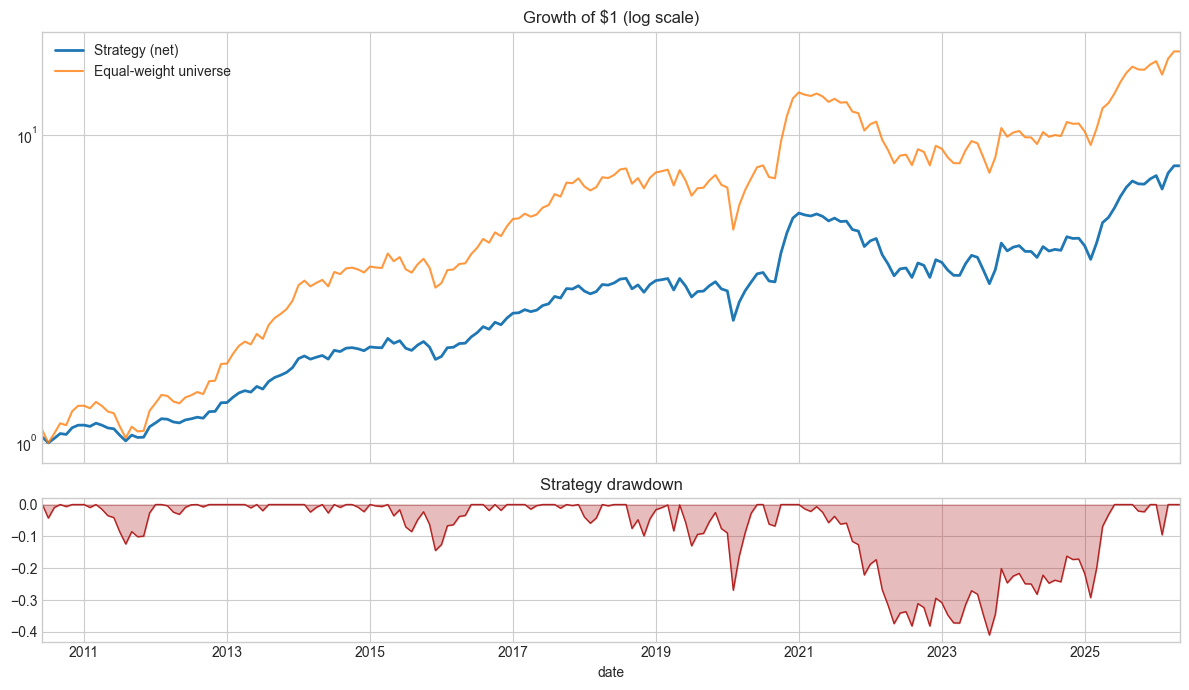

In [3]:
fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True, gridspec_kw={'height_ratios':[3,1]})
metrics.cumulative(bt['net']).plot(ax=ax[0], label='Strategy (net)', lw=2)
metrics.cumulative(bench).plot(ax=ax[0], label='Equal-weight universe', lw=1.5, alpha=0.8)
ax[0].set_yscale('log'); ax[0].set_title('Growth of $1 (log scale)'); ax[0].legend()

metrics.drawdown(bt['net']).plot(ax=ax[1], color='firebrick', lw=1)
ax[1].fill_between(bt.index, metrics.drawdown(bt['net']), 0, color='firebrick', alpha=0.3)
ax[1].set_title('Strategy drawdown')
plt.tight_layout(); plt.show()

## FF5 + Momentum attribution

Is the return genuine alpha, or just repackaged factor exposure? The intercept is
what the known factors *don't* explain.

In [4]:
attr = attribution.factor_attribution(bt['net'], factors)
print(f"Annualized alpha: {attr['alpha_annual']:.2%}  (t = {attr['alpha_tstat']:.2f})")
print(f"R^2: {attr['r_squared']:.2f}  |  months: {attr['n_months']}")
print('\nCoefficient table (excess-return regression):')
attr['coef_table'].round(3)

Annualized alpha: 18.89%  (t = 3.32)
R^2: 0.06  |  months: 190

Coefficient table (excess-return regression):


,coef,t_stat
alpha,0.015,3.323
Mkt-RF,-0.167,-1.540
SMB,0.045,0.234
HML,-0.161,-0.880
RMW,-0.582,-2.527
CMA,0.010,0.040
MOM,-0.159,-1.165


## Caveats (always report these)

- **Survivorship bias**: universe is *current* listings; failed/delisted names are excluded, inflating results. A point-in-time universe needs a paid source.
- **Quick sample**: ~30 names; not investable conclusions. Run the full universe for real numbers.
- **Costs**: spread+commission modeled via turnover; real fills may differ.

## Strategy B pipeline complete

data layer (EDGAR PIT) → feature panel → signal IC → walk-forward ML → long-only
backtest + attribution. Next: run the **full universe**, then iterate on features/models.